In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../data/output.csv')
print(df.shape)
df.head()

(27481, 13)


,Unnamed: 0.1,Unnamed: 0,textID,text,selected_text,sentiment,Time of Tweet,Age of User,Country,Population -2020,Land Area (KmÂ²),Density (P/KmÂ²),cleaned_text
0,0,0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral,morning,0-20,Afghanistan,38928346,652860.0,60,"I`d have responded, if I were going"
1,1,1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative,noon,21-30,Albania,2877797,27400.0,105,Sooo SAD I will miss you here in San Diego!!!
2,2,2,088c60f138,my boss is bullying me...,bullying me,negative,night,31-45,Algeria,43851044,2381740.0,18,my boss is bullying me...
3,3,3,9642c003ef,what interview! leave me alone,leave me alone,negative,morning,46-60,Andorra,77265,470.0,164,what interview! leave me alone
4,4,4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative,noon,60-70,Angola,32866272,1246700.0,26,"Sons of ***, why couldn`t they put them on th..."


In [3]:
print(df.info())
print("\nMissing values:\n", df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27481 entries, 0 to 27480
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0.1      27481 non-null  int64  
 1   Unnamed: 0        27481 non-null  int64  
 2   textID            27481 non-null  object 
 3   text              27480 non-null  object 
 4   selected_text     27480 non-null  object 
 5   sentiment         27481 non-null  object 
 6   Time of Tweet     27481 non-null  object 
 7   Age of User       27481 non-null  object 
 8   Country           27481 non-null  object 
 9   Population -2020  27481 non-null  int64  
 10  Land Area (KmÂ²)  27481 non-null  float64
 11  Density (P/KmÂ²)  27481 non-null  int64  
 12  cleaned_text      27480 non-null  object 
dtypes: float64(1), int64(4), object(8)
memory usage: 2.7+ MB
None

Missing values:
 Unnamed: 0.1        0
Unnamed: 0          0
textID              0
text                1
selected_text

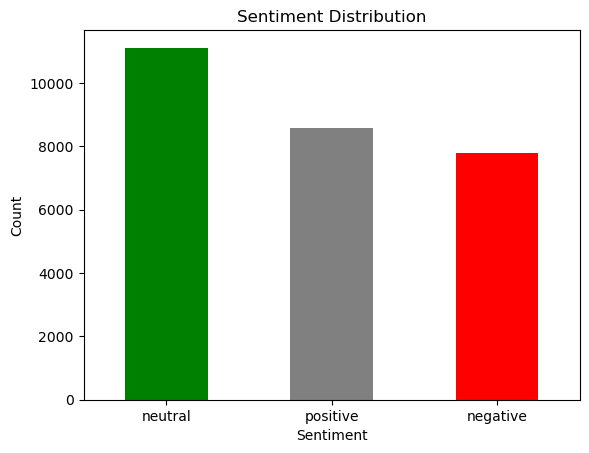

In [4]:
df['sentiment'].value_counts().plot(kind='bar', color=['green', 'gray', 'red'])
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

In [5]:
for sentiment in df['sentiment'].unique():
    print(f"\n--- {sentiment.upper()} ---")
    print(df[df['sentiment'] == sentiment]['cleaned_text'].sample(3).values)


--- NEUTRAL ---
['I just watched 7 pounds, maaannn!'
 'NEW YORK DOLLS TOMORROW NIGHT @ THE DEPOT CANCELLED REFUNDS AVAILABLE AT POINT OF PURCHASE.'
 'Happy its the weekend...LOVE has knocked me down ya`ll!!!']

--- NEGATIVE ---
['Steve makes fruit smoothies for me each day & they are berry delicious, I made mine today & it was berry, berry bad'
 '_Molotov Go much bamboo? Would you like to attempt to structure a sentence that makes sense? Why did i fail english and others pass?'
 'Does anyone know how to scale a pic down I`m trying to change my pic but all my pics r 2 big n I keep cropping them...HELP']

--- POSITIVE ---
[' Fab new pic by the way'
 'Sitting in an empty yearbook room. attempting to figure this asap out lol'
 ' Thanks']


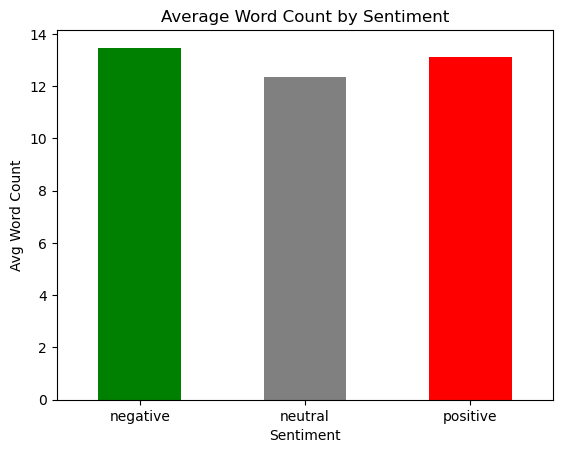

In [6]:
df['text_length'] = df['cleaned_text'].apply(lambda x: len(str(x).split()))

df.groupby('sentiment')['text_length'].mean().plot(kind='bar', color=['green', 'gray', 'red'])
plt.title('Average Word Count by Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Avg Word Count')
plt.xticks(rotation=0)
plt.show()